## Классная работа

In [45]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from random import randint

import numpy as np

#### Создание класса нейросети

In [26]:
class MyClass(nn.Module):
    def __init__(self, input_dim, num_hidden, output_dim):
        super().__init__()
        self.layer1 = nn.Linear(input_dim, num_hidden)
        self.layer2 = nn.Linear(num_hidden, output_dim)

    def forward(self, x):
        """Прямой проход по НС"""
        u1 = self.layer1(x)
        s1 = F.tanh(u1)

        u2 = self.layer2(s1)
        s2 = F.tanh(u2)

        return s2

In [27]:
model = MyClass(3, 2, 1)
model

MyClass(
  (layer1): Linear(in_features=3, out_features=2, bias=True)
  (layer2): Linear(in_features=2, out_features=1, bias=True)
)

#### Параметры нейросети

In [28]:
gen_p = model.parameters()
list(gen_p)  # потому что это генератор

[Parameter containing:
 tensor([[-0.0853,  0.4243,  0.1028],
         [ 0.3480, -0.5223,  0.3847]], requires_grad=True),
 Parameter containing:
 tensor([ 0.3681, -0.5181], requires_grad=True),
 Parameter containing:
 tensor([[-0.1909,  0.1367]], requires_grad=True),
 Parameter containing:
 tensor([0.0764], requires_grad=True)]

#### Объявление оптимизатора и функции потерь 

In [29]:
optimizer = optim.RMSprop(params=model.parameters(), lr=0.01)
loss_func = torch.nn.MSELoss()

#### Обучение

In [30]:
model.train()  # переводим сеть в режим обучения

MyClass(
  (layer1): Linear(in_features=3, out_features=2, bias=True)
  (layer2): Linear(in_features=2, out_features=1, bias=True)
)

In [31]:
x_train = torch.FloatTensor([(-1, -1, -1), (-1, -1, 1), (-1, 1, -1), (-1, 1, 1),
                            (1, -1, -1), (1, -1, 1), (1, 1, -1), (1, 1, 1)])
y_train = torch.FloatTensor([-1, 1, -1, 1, -1, 1, -1, -1])

In [32]:
for _ in range(1000):
    k = randint(0, len(x_train)-1)
    y = model(x_train[k])
    loss = loss_func(y.squeeze(), y_train[k])

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

#### Оценка

In [33]:
model.eval()  # возвращаем в режим эксплуатации

MyClass(
  (layer1): Linear(in_features=3, out_features=2, bias=True)
  (layer2): Linear(in_features=2, out_features=1, bias=True)
)

In [35]:
for x, d in zip(x_train, y_train):
    # model.requires_frad_(False)  # так тоже можно отключать градиенты
    with torch.no_grad():  # отключает поддержку локальных градиентов
        y = model(x)
        print(f'Выходное значение НС: {y.data} => {1 if y.data >= 0 else -1}')

Выходное значение НС: tensor([-0.9864]) => -1
Выходное значение НС: tensor([0.9989]) => 1
Выходное значение НС: tensor([-0.9992]) => -1
Выходное значение НС: tensor([0.9860]) => 1
Выходное значение НС: tensor([-0.9992]) => -1
Выходное значение НС: tensor([0.9864]) => 1
Выходное значение НС: tensor([-0.9994]) => -1
Выходное значение НС: tensor([-0.9834]) => -1


## Домашняя работа

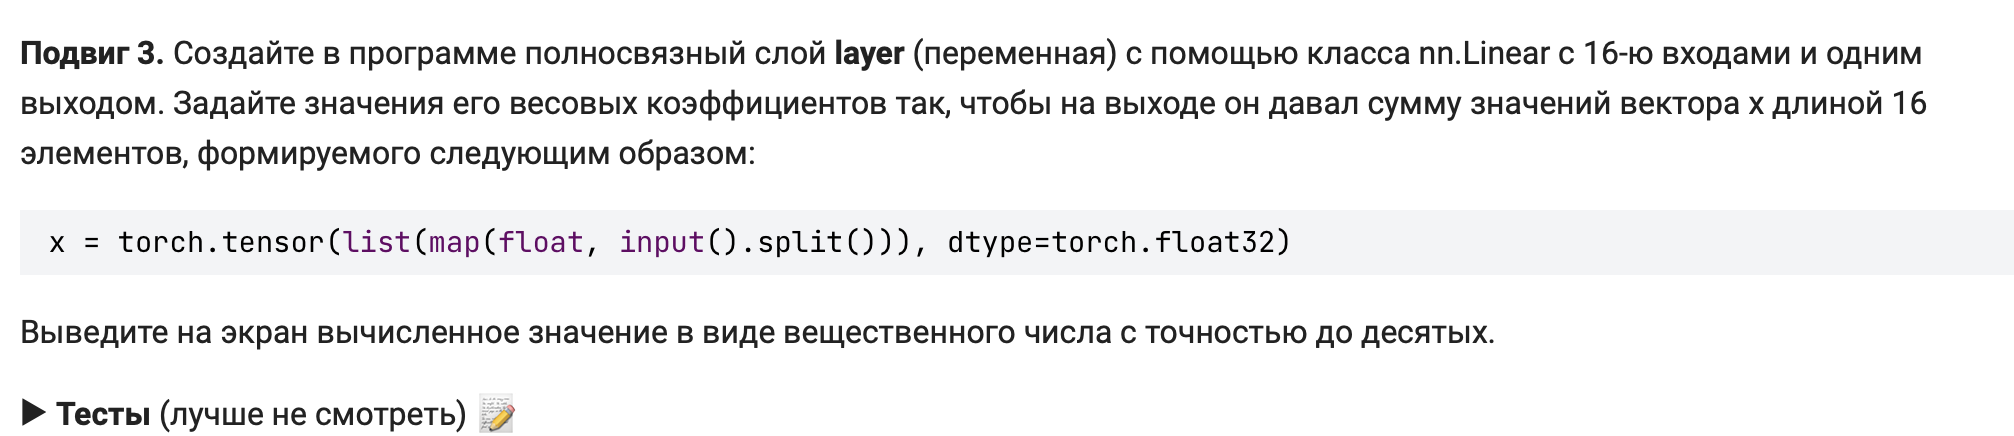

In [37]:
# тензор x в программе не менять
x = torch.tensor(list(map(float, input().split())), dtype=torch.float32)

# здесь продолжайте программу
layer = nn.Linear(16, 1)
layer.weights = torch.ones(16)

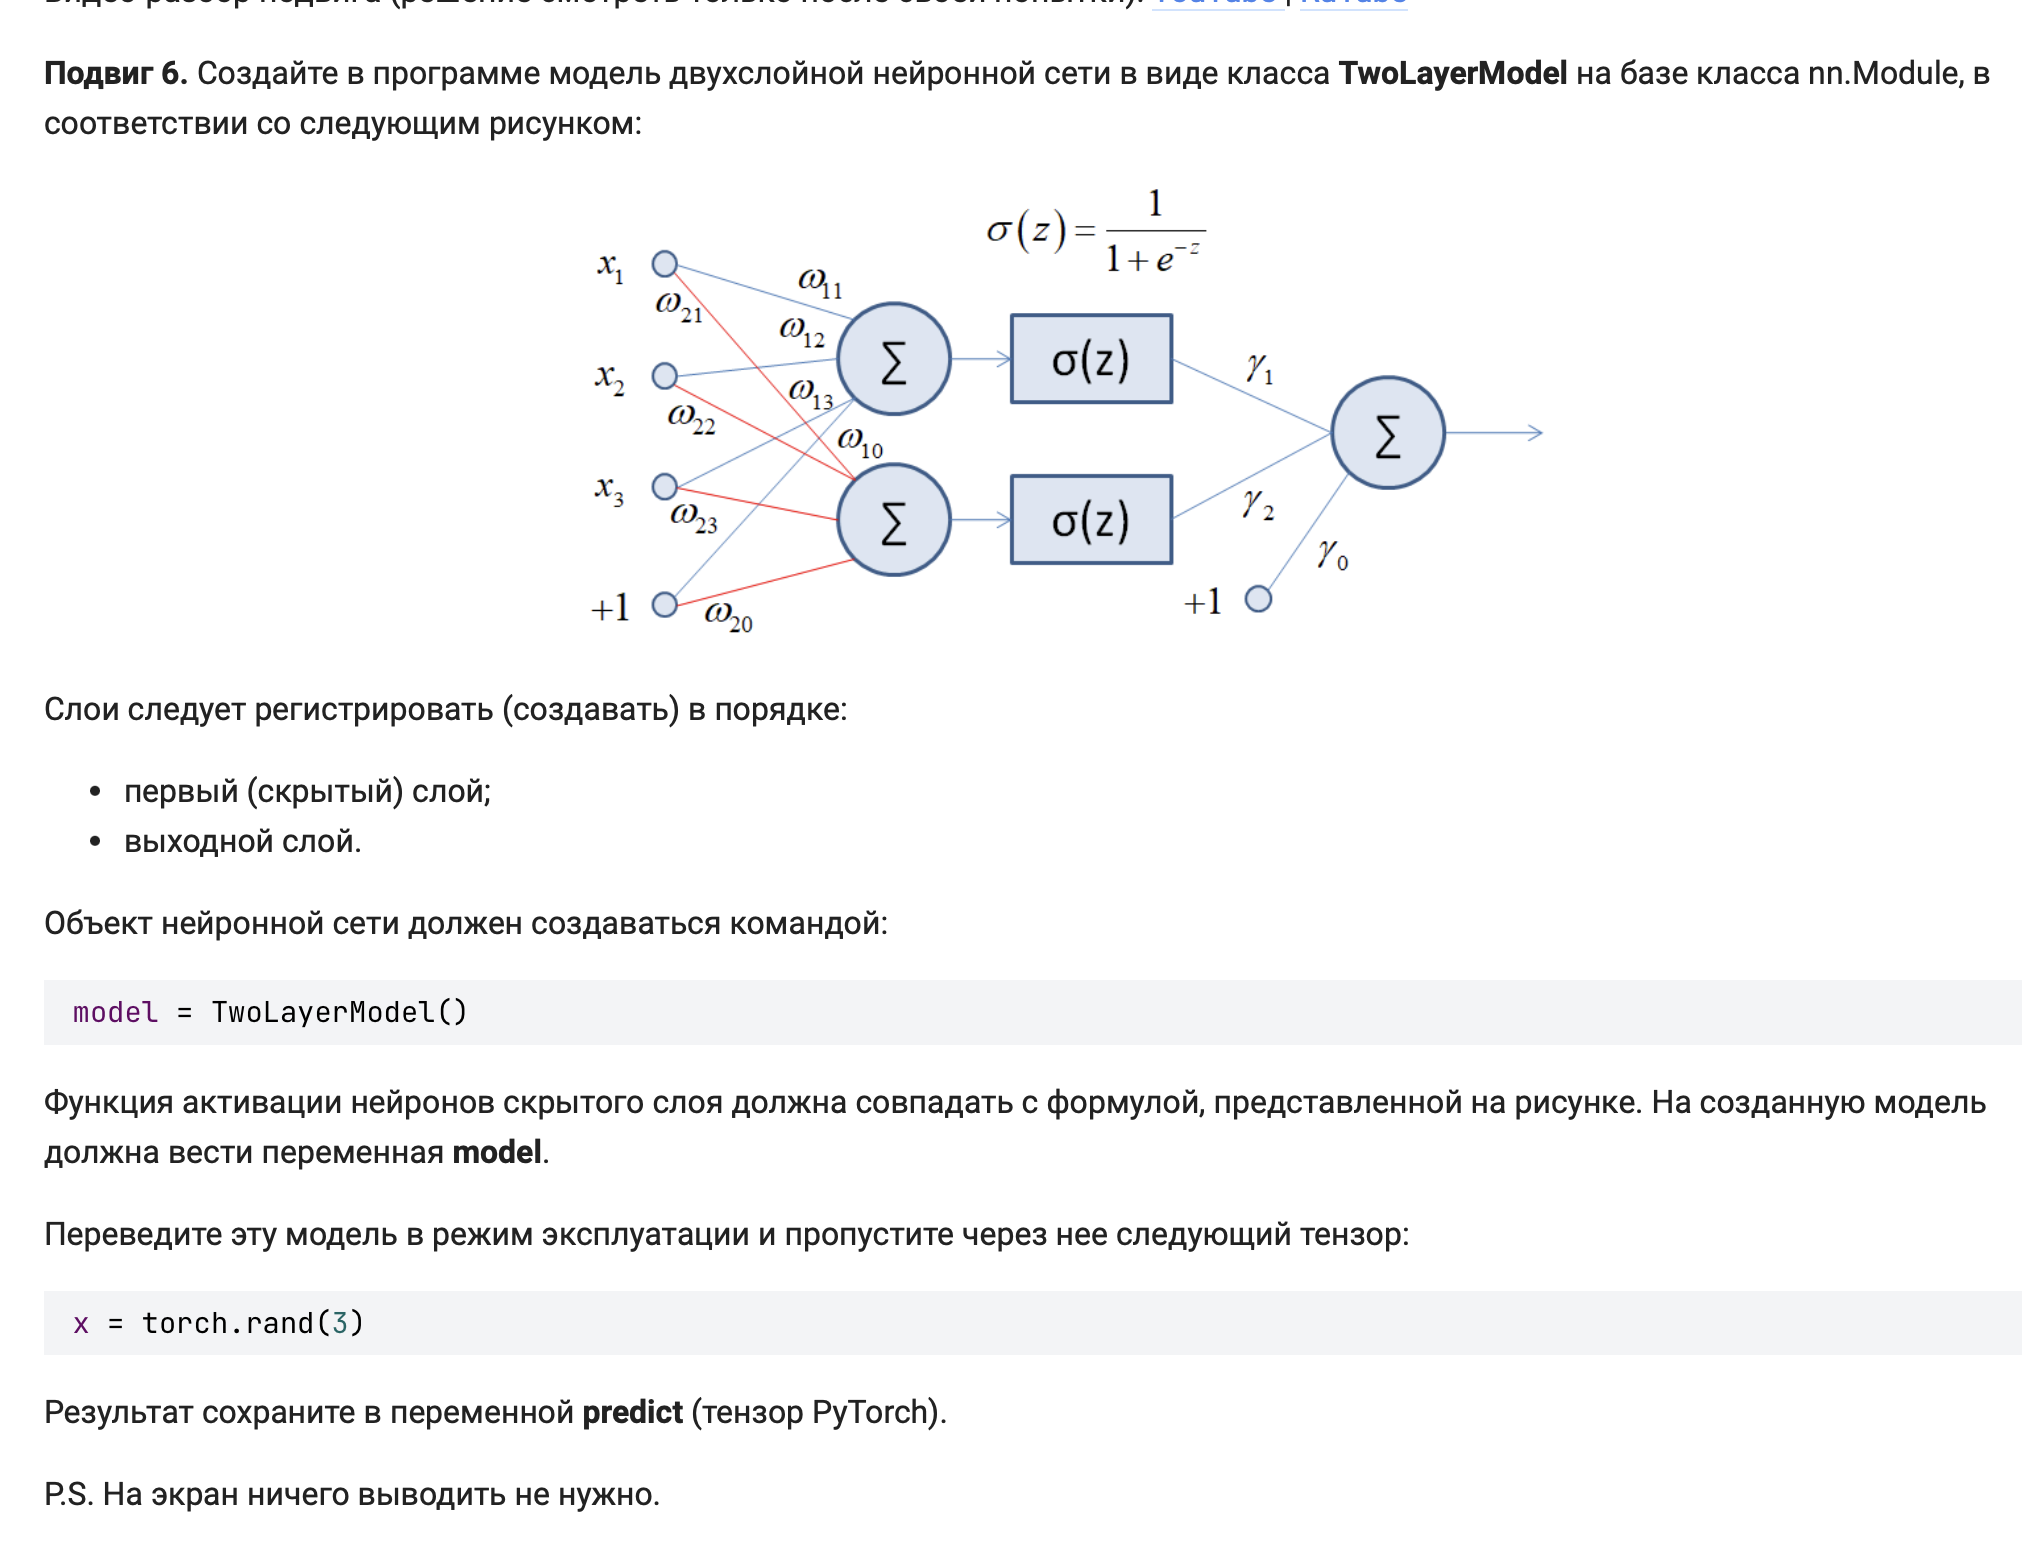

In [40]:
# здесь объявляйте класс модели (обязательно до тензора x)
class TwoLayerModel(nn.Module):
    def __init__(self, inp, hid, out):
        super().__init__()
        self.l1 = nn.Linear(inp, hid)
        self.l2 = nn.Linear(hid, out)
    
    def forward(self, x):
        z = self.l1(x)
        u = z.sigmoid()

        y = self.l2(u)

        return y

x = torch.rand(3) # тензор x в программе не менять

# здесь продолжайте программу
model = TwoLayerModel(3, 2, 1)
model.eval()

predict = model(x)
predict

tensor([-0.2132], grad_fn=<ViewBackward0>)

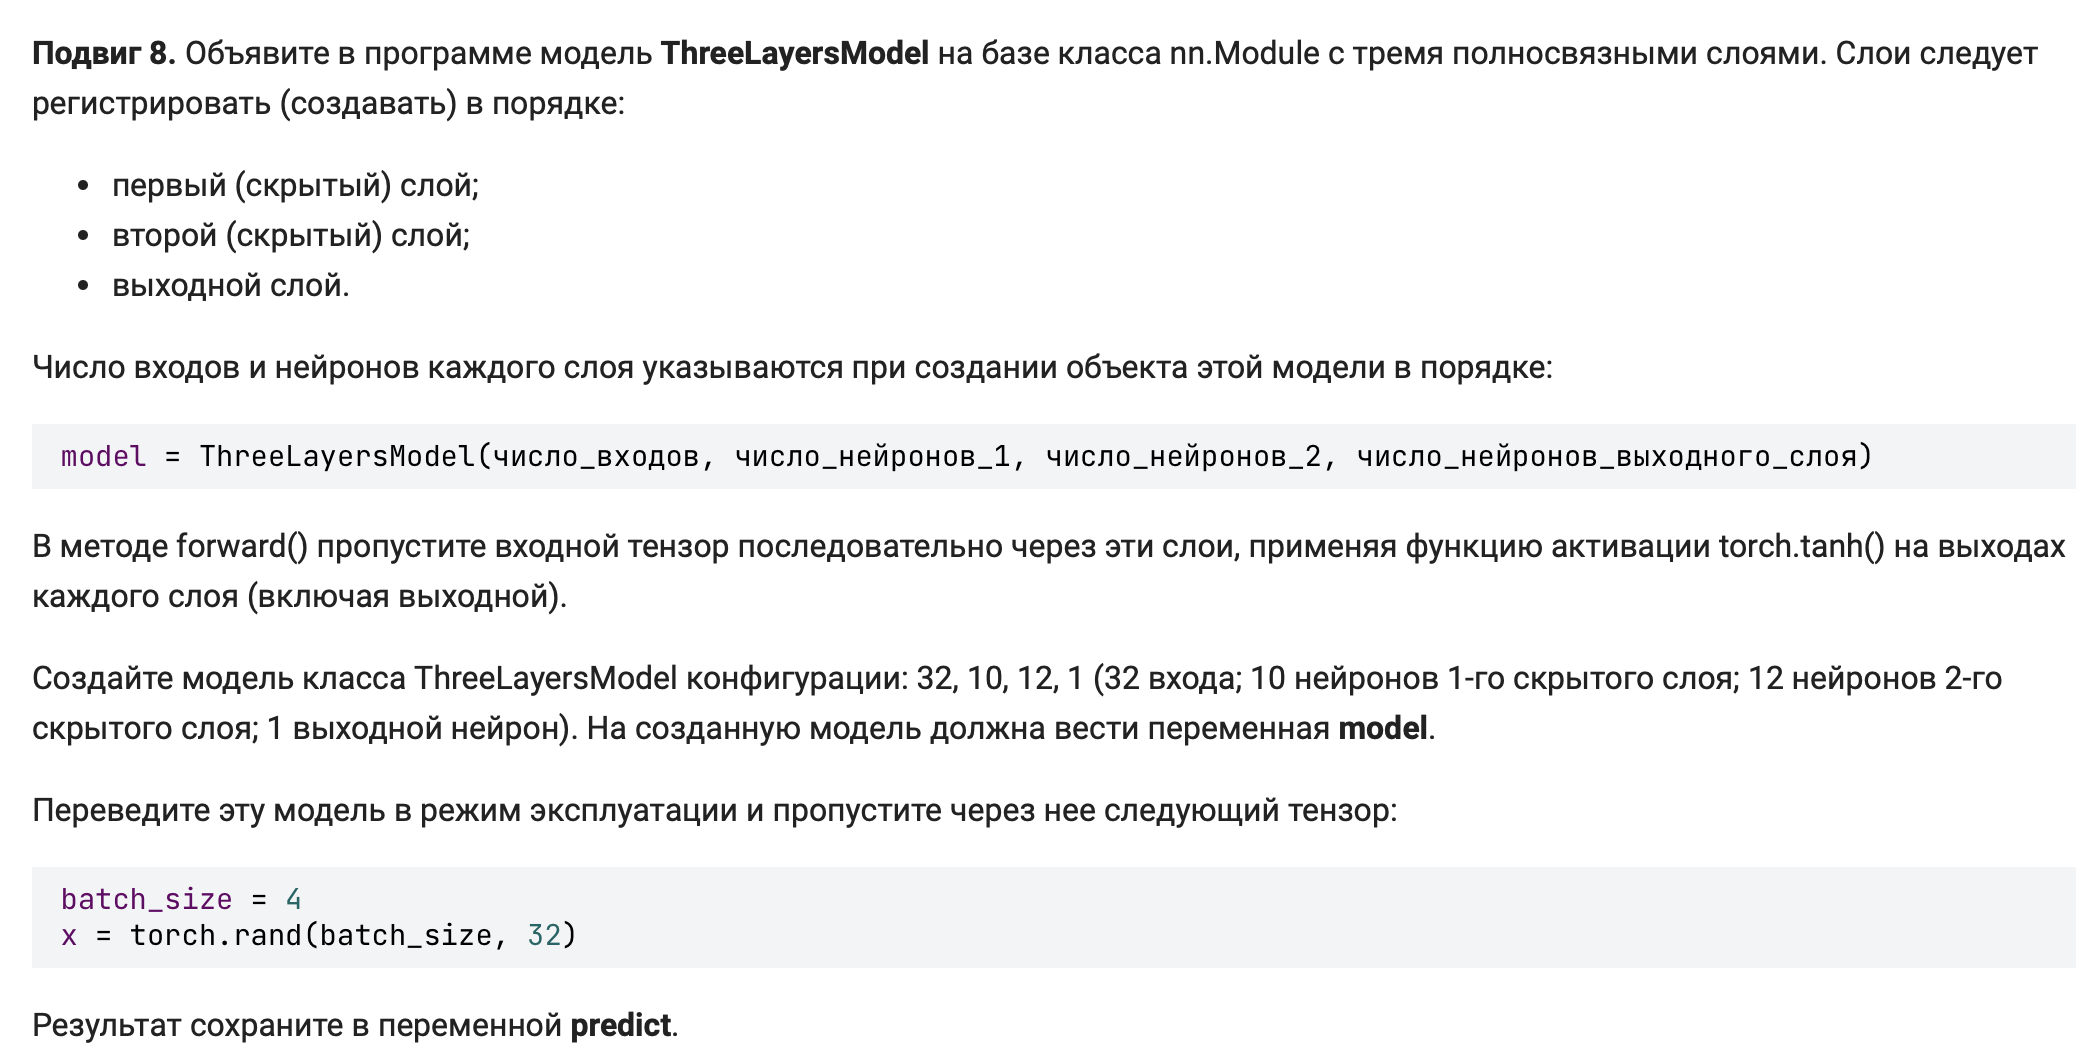

In [41]:
# здесь объявляйте класс модели (обязательно до тензора x)
class ThreeLayersModel(nn.Module):
    def __init__(self, inp, hid1, hid2, out):
        super().__init__()
        self.l1 = nn.Linear(inp, hid1)
        self.l2 = nn.Linear(hid1, hid2)
        self.l3 = nn.Linear(hid2, out)

    def forward(self, x):
        z1 = self.l1(x)
        u1 = z1.tanh()

        z2 = self.l2(u1)
        u2 = z2.tanh()

        z3 = self.l3(u2)
        u3 = z3.tanh()

        return u3

batch_size = 4
x = torch.rand(batch_size, 32) # тензор x в программе не менять

# здесь продолжайте программу
model = ThreeLayersModel(32, 10, 12, 1)
model.eval()

predict = model(x)

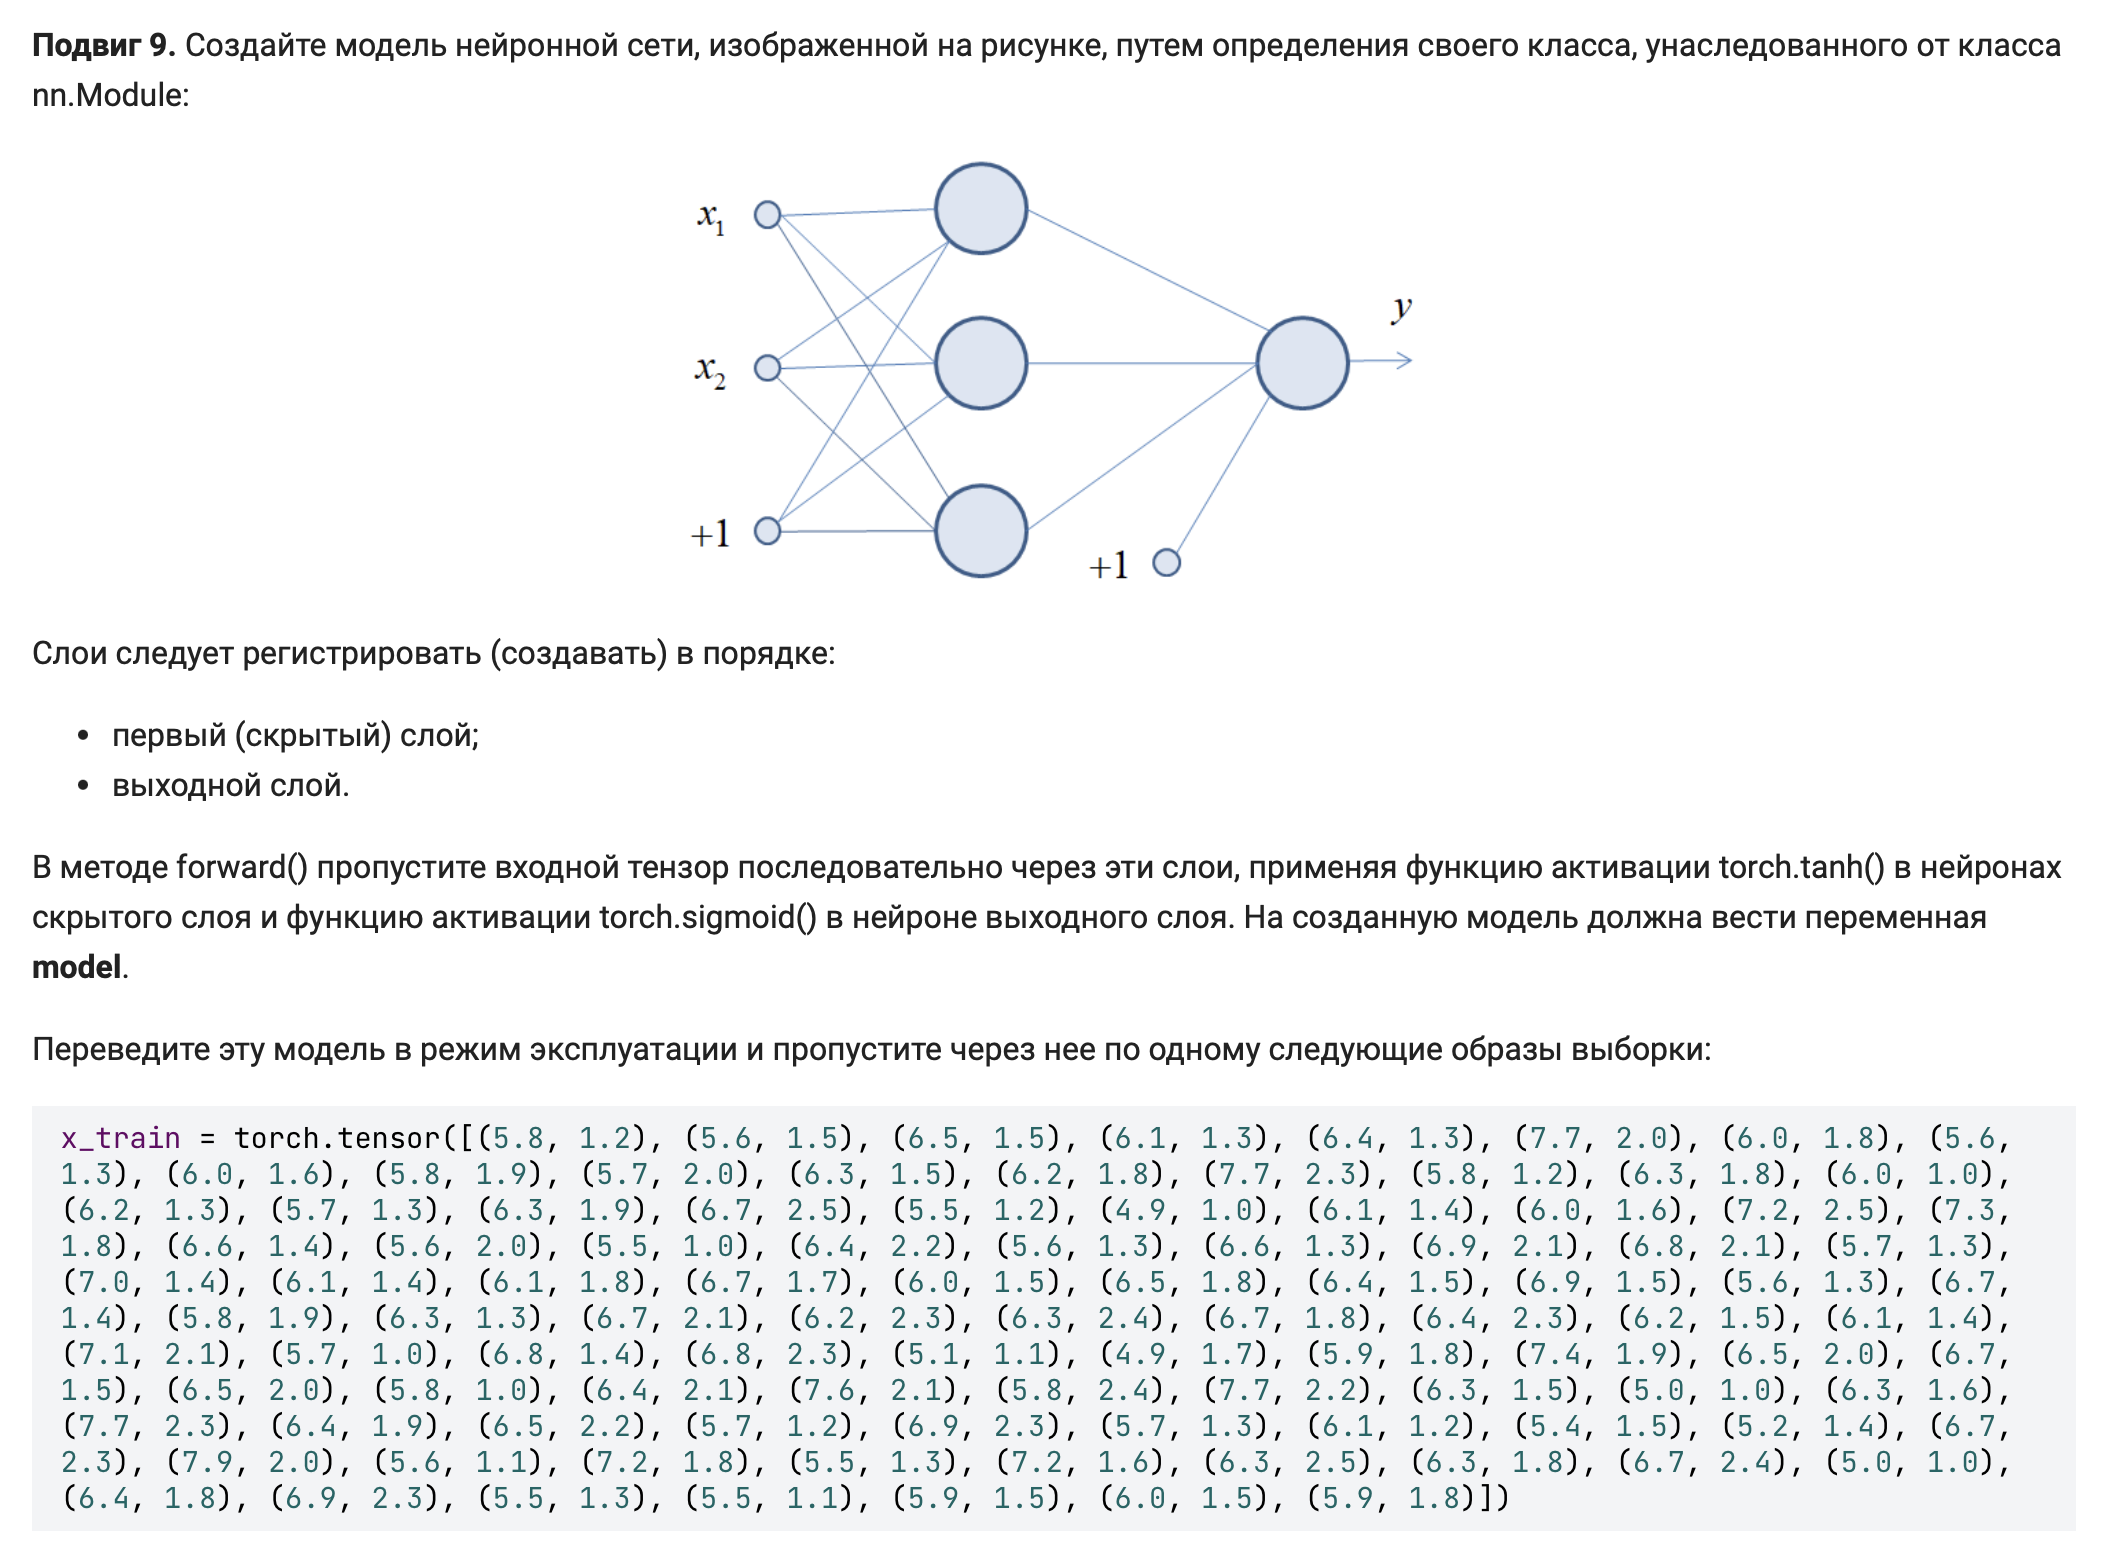
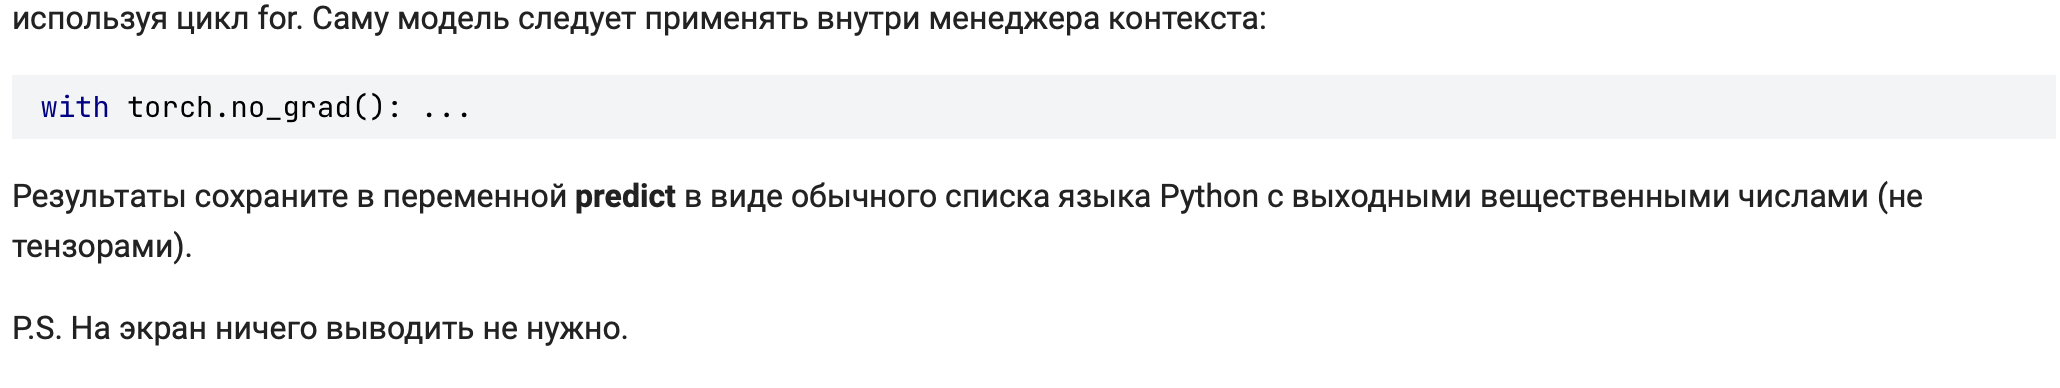

In [ ]:
# здесь объявляйте класс модели (обязательно до тензора x_train)
class Model(nn.Module):
    def __init__(self, inp, hid, out):
        super().__init__()
        self.l1 = nn.Linear(inp, hid)
        self.l2 = nn.Linear(hid, out)
    
    def forward(self, x):
        u1 = self.l1(x).tanh()
        y = self.l2(u1).sigmoid()

        return y

# тензор x_train в программе не менять
x_train = torch.tensor([(5.8, 1.2), (5.6, 1.5), (6.5, 1.5), (6.1, 1.3), (6.4, 1.3), (7.7, 2.0), (6.0, 1.8), (5.6, 1.3), (6.0, 1.6), (5.8, 1.9), (5.7, 2.0), (6.3, 1.5), (6.2, 1.8), (7.7, 2.3), (5.8, 1.2), (6.3, 1.8), (6.0, 1.0), (6.2, 1.3), (5.7, 1.3), (6.3, 1.9), (6.7, 2.5), (5.5, 1.2), (4.9, 1.0), (6.1, 1.4), (6.0, 1.6), (7.2, 2.5), (7.3, 1.8), (6.6, 1.4), (5.6, 2.0), (5.5, 1.0), (6.4, 2.2), (5.6, 1.3), (6.6, 1.3), (6.9, 2.1), (6.8, 2.1), (5.7, 1.3), (7.0, 1.4), (6.1, 1.4), (6.1, 1.8), (6.7, 1.7), (6.0, 1.5), (6.5, 1.8), (6.4, 1.5), (6.9, 1.5), (5.6, 1.3), (6.7, 1.4), (5.8, 1.9), (6.3, 1.3), (6.7, 2.1), (6.2, 2.3), (6.3, 2.4), (6.7, 1.8), (6.4, 2.3), (6.2, 1.5), (6.1, 1.4), (7.1, 2.1), (5.7, 1.0), (6.8, 1.4), (6.8, 2.3), (5.1, 1.1), (4.9, 1.7), (5.9, 1.8), (7.4, 1.9), (6.5, 2.0), (6.7, 1.5), (6.5, 2.0), (5.8, 1.0), (6.4, 2.1), (7.6, 2.1), (5.8, 2.4), (7.7, 2.2), (6.3, 1.5), (5.0, 1.0), (6.3, 1.6), (7.7, 2.3), (6.4, 1.9), (6.5, 2.2), (5.7, 1.2), (6.9, 2.3), (5.7, 1.3), (6.1, 1.2), (5.4, 1.5), (5.2, 1.4), (6.7, 2.3), (7.9, 2.0), (5.6, 1.1), (7.2, 1.8), (5.5, 1.3), (7.2, 1.6), (6.3, 2.5), (6.3, 1.8), (6.7, 2.4), (5.0, 1.0), (6.4, 1.8), (6.9, 2.3), (5.5, 1.3), (5.5, 1.1), (5.9, 1.5), (6.0, 1.5), (5.9, 1.8)])

# здесь продолжайте программу
model = Model(2, 3, 1)
model.eval()

predict = []
with torch.no_grad():
    for xx in x_train:
        predict += [model(xx).item()]

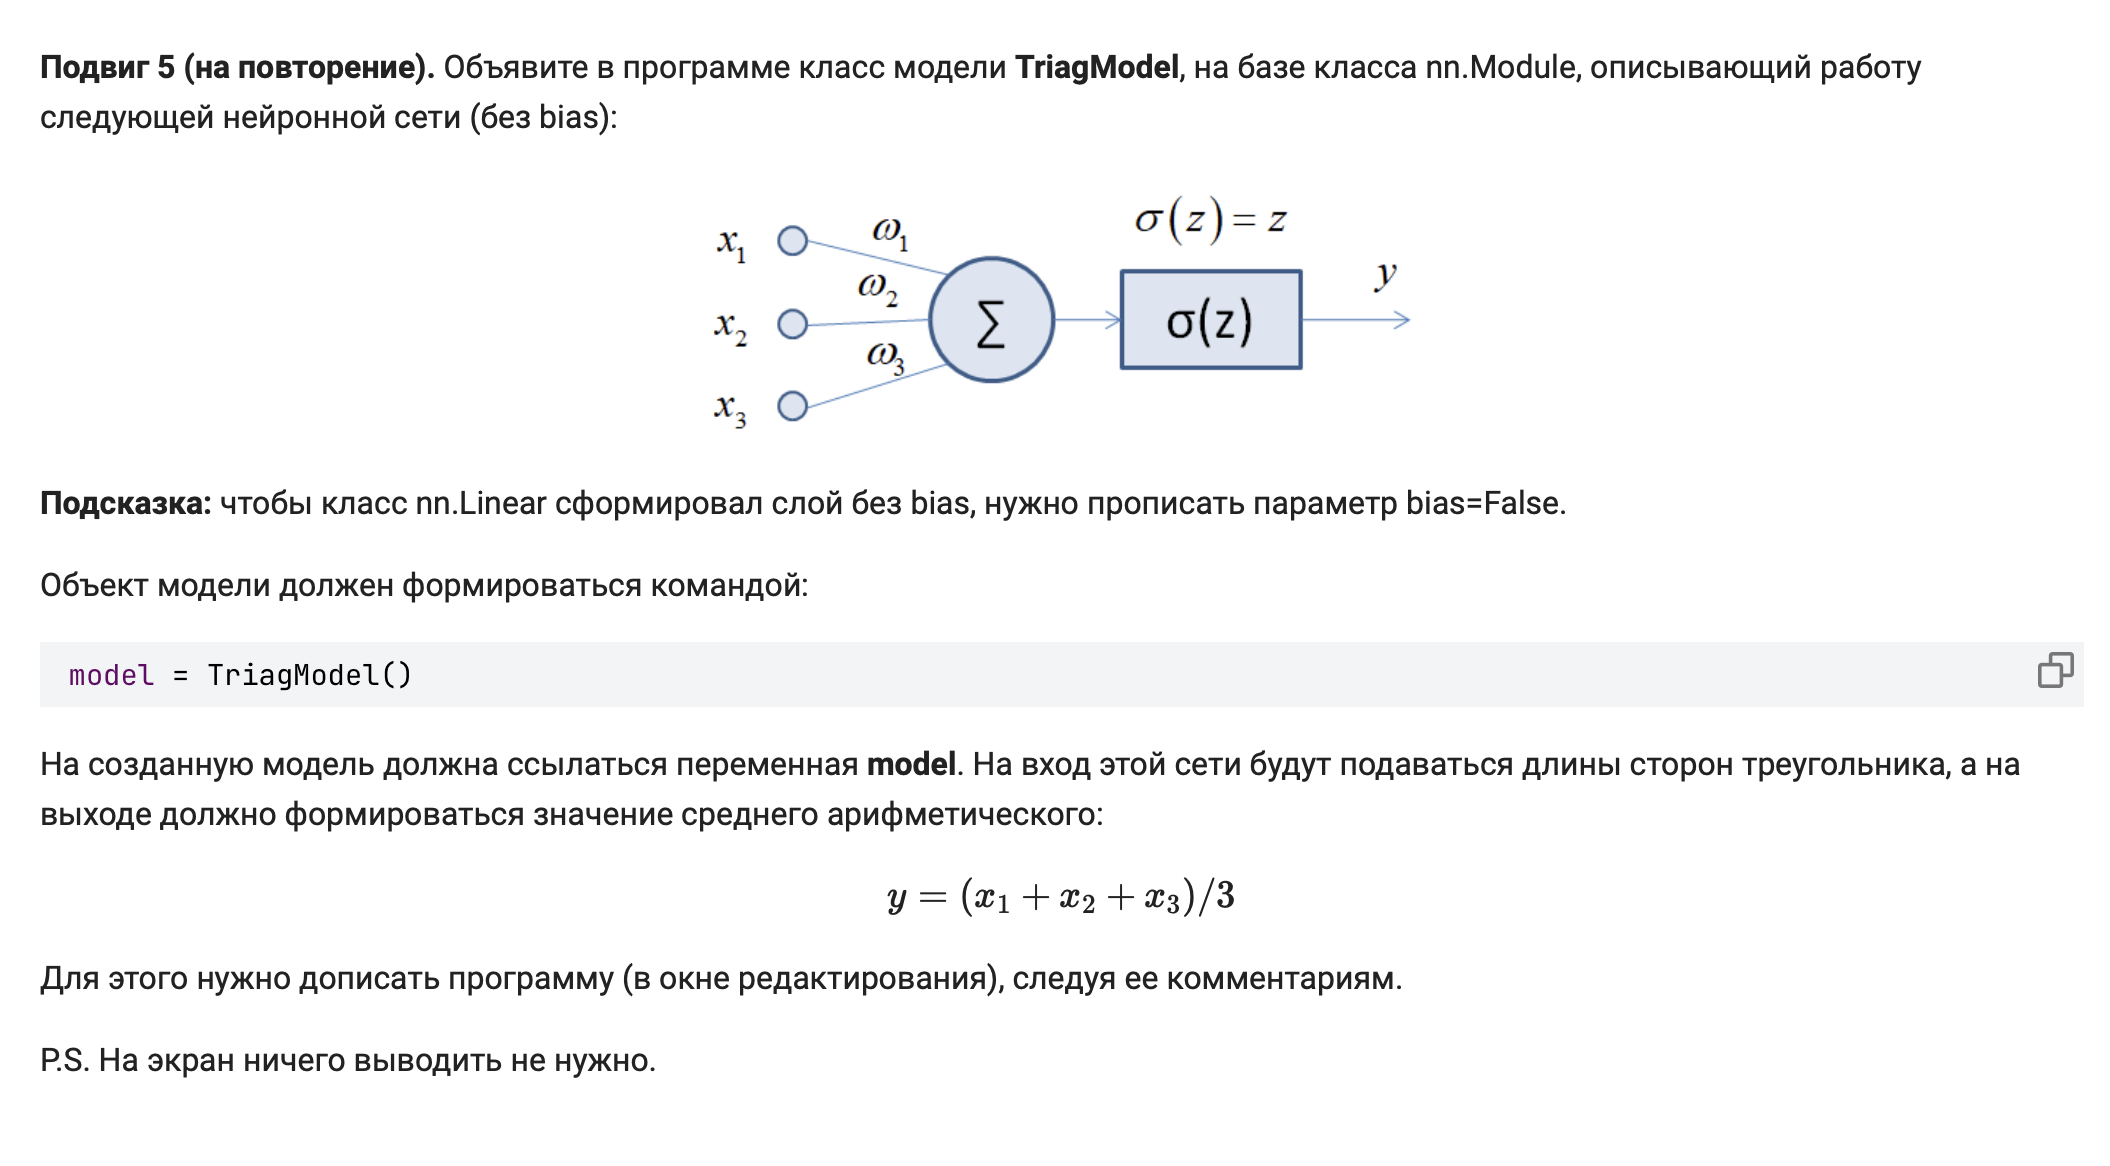

In [48]:
# здесь объявляйте класс TriagModel
class TriagModel(nn.Module):
    def __init__(self, inp, out):
        super().__init__()
        self.l1 = nn.Linear(inp, out, bias=False)

    def forward(self, x):
        y = self.l1(x)
        return y

np.random.seed(1)
torch.manual_seed(1)

total = 100
x_train = torch.randint(1, 10, (total, 3), dtype=torch.float32)
y_train = x_train.sum(dim=1) / 3

# здесь создавайте модель (model)
model = TriagModel(3, 1)
# переведите модель в режим обучения
model.train()

lr = 0.01 # шаг обучения
N = 1000 # число итераций SGD

optimizer = optim.Adam(params=model.parameters(), lr=lr)  # здесь сформируйте оптимизатор Adam с параметрами модели и шагом обучения lr
loss_func = nn.MSELoss()  # здесь создайте функцию потерь с помощью класса nn.MSELoss

for _ in range(N):
    k = np.random.randint(0, total)
    # пропустите через модель k-й образ выборки x_train и вычислите прогноз predict
    pred = model(x_train[k])
    loss = loss_func(pred.squeeze(), y_train[k])  # вычислите значение функции потерь и сохраните результат в переменной loss

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

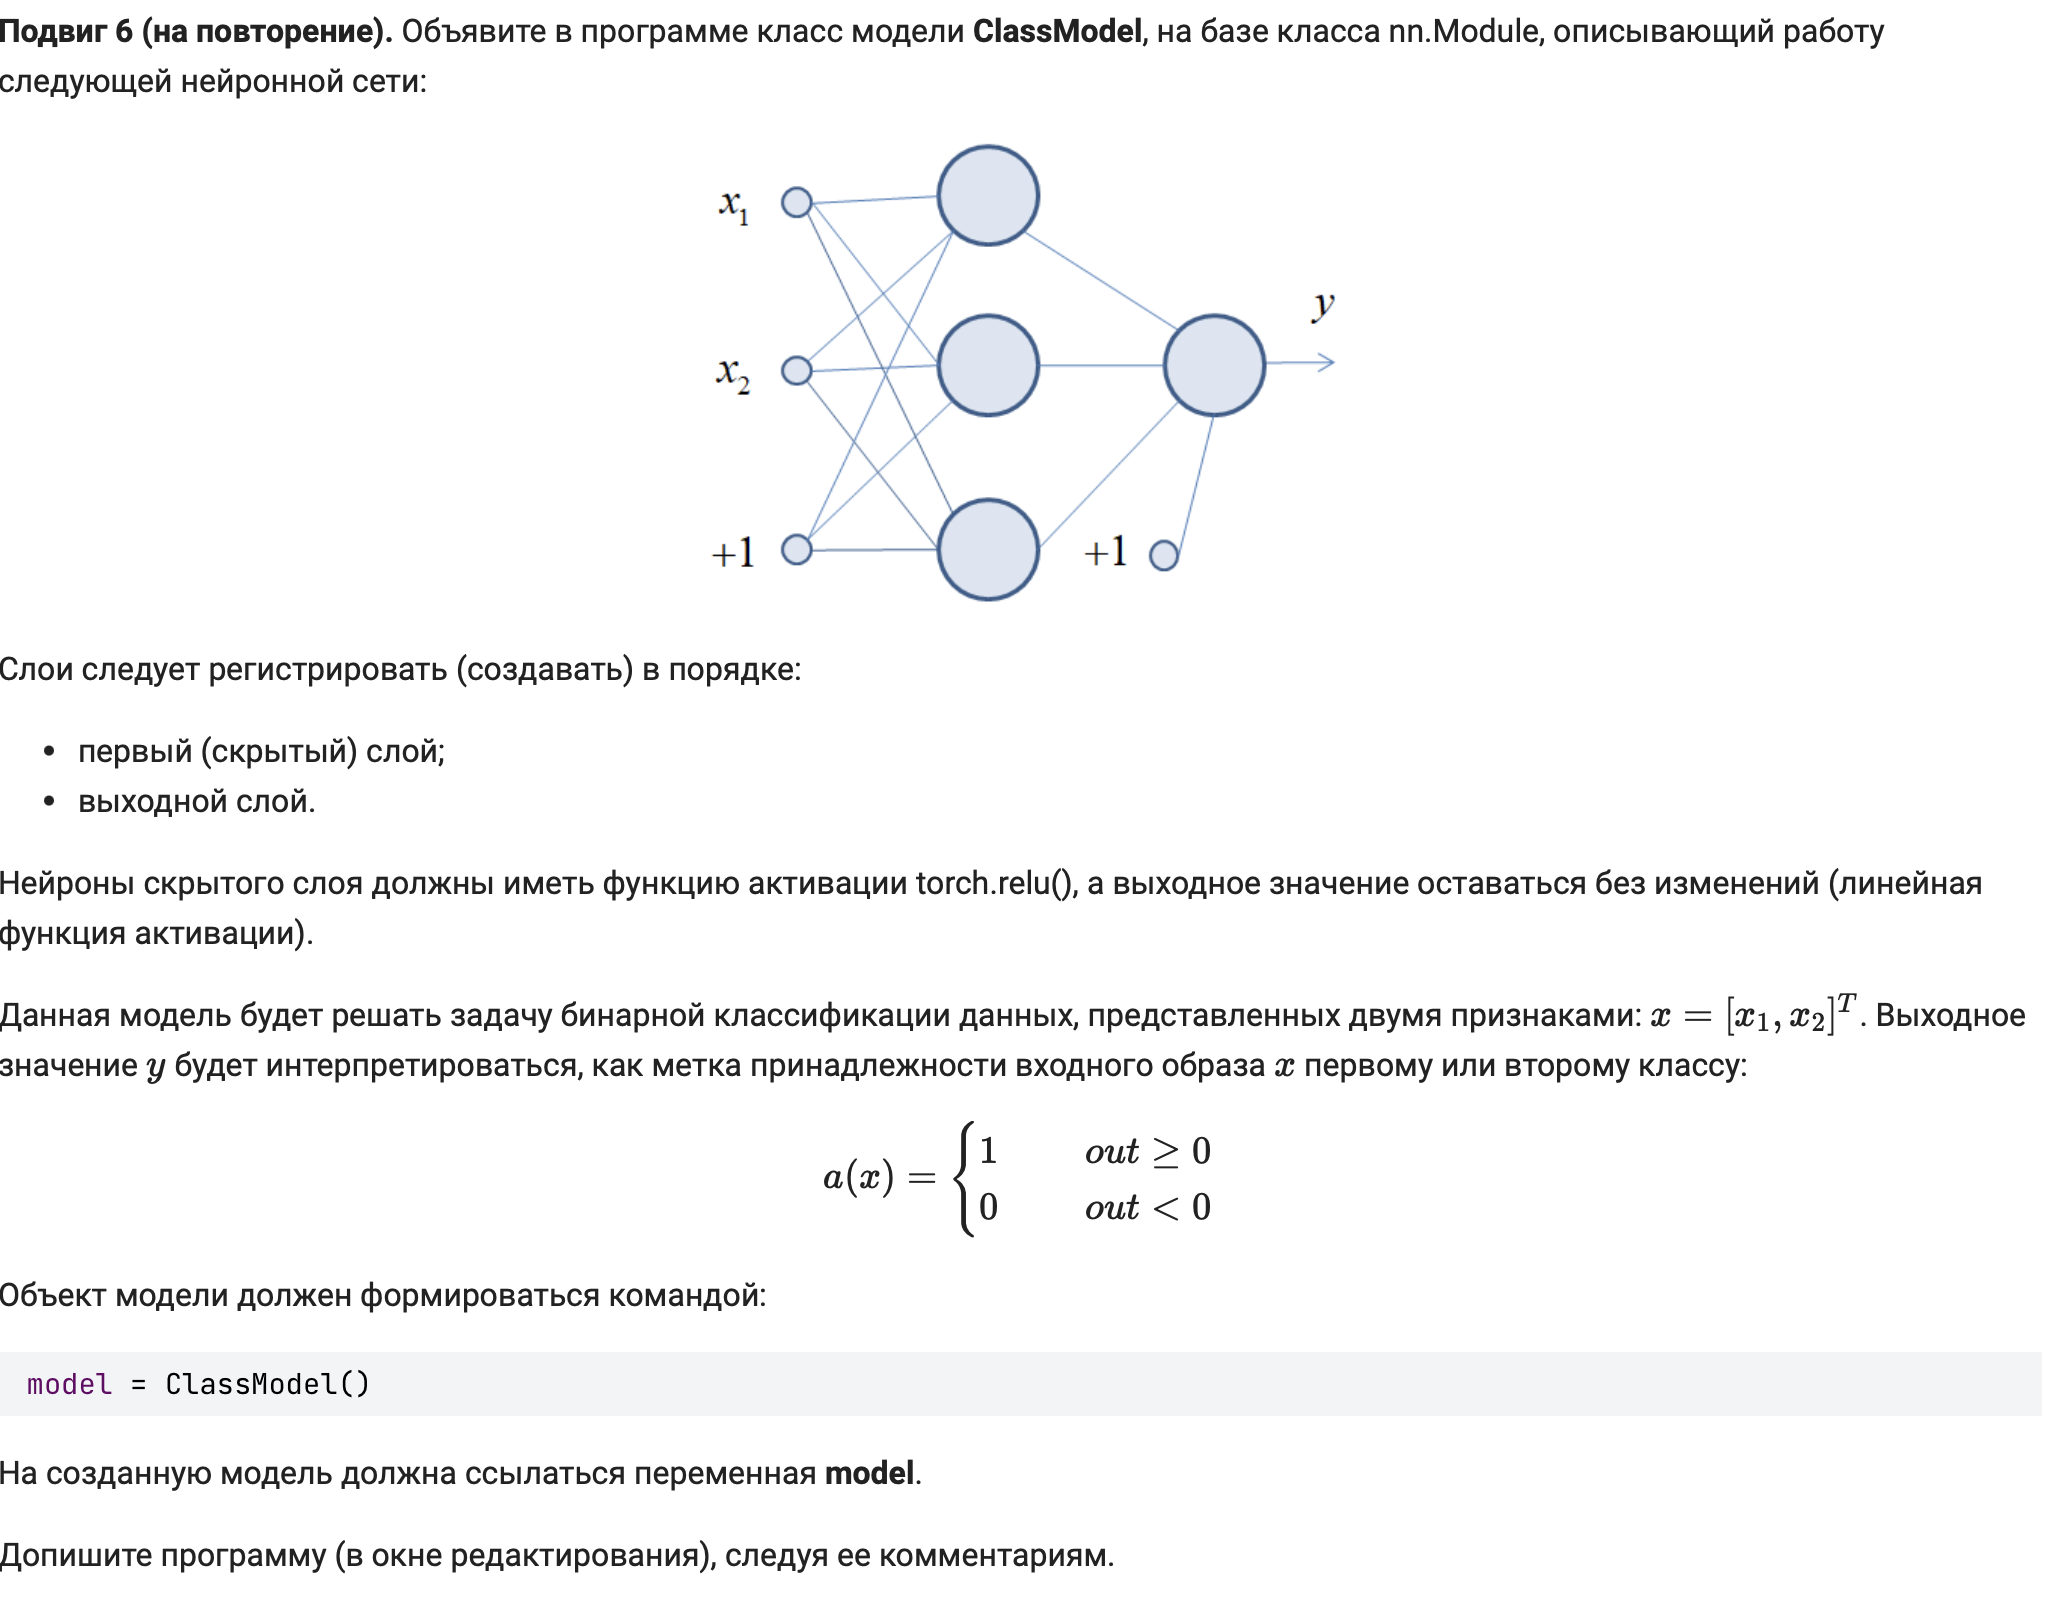

In [53]:
# здесь объявляйте класс ClassModel
class ClassModel(nn.Module):
    def __init__(self, inp, hid, out):
        super().__init__()
        self.l1 = nn.Linear(inp, hid)
        self.l2 = nn.Linear(hid, out)

    def forward(self, x):
        u1 = self.l1(x).relu()
        y = self.l2(u1)

        return y

np.random.seed(1)
torch.manual_seed(1)

# обучающая выборка: x_train - входные значения; y_train - целевые значения
x_train = torch.tensor([(5.8, 1.2), (5.6, 1.5), (6.5, 1.5), (6.1, 1.3), (6.4, 1.3), (7.7, 2.0), (6.0, 1.8), (5.6, 1.3), (6.0, 1.6), (5.8, 1.9), (5.7, 2.0), (6.3, 1.5), (6.2, 1.8), (7.7, 2.3), (5.8, 1.2), (6.3, 1.8), (6.0, 1.0), (6.2, 1.3), (5.7, 1.3), (6.3, 1.9), (6.7, 2.5), (5.5, 1.2), (4.9, 1.0), (6.1, 1.4), (6.0, 1.6), (7.2, 2.5), (7.3, 1.8), (6.6, 1.4), (5.6, 2.0), (5.5, 1.0), (6.4, 2.2), (5.6, 1.3), (6.6, 1.3), (6.9, 2.1), (6.8, 2.1), (5.7, 1.3), (7.0, 1.4), (6.1, 1.4), (6.1, 1.8), (6.7, 1.7), (6.0, 1.5), (6.5, 1.8), (6.4, 1.5), (6.9, 1.5), (5.6, 1.3), (6.7, 1.4), (5.8, 1.9), (6.3, 1.3), (6.7, 2.1), (6.2, 2.3), (6.3, 2.4), (6.7, 1.8), (6.4, 2.3), (6.2, 1.5), (6.1, 1.4), (7.1, 2.1), (5.7, 1.0), (6.8, 1.4), (6.8, 2.3), (5.1, 1.1), (4.9, 1.7), (5.9, 1.8), (7.4, 1.9), (6.5, 2.0), (6.7, 1.5), (6.5, 2.0), (5.8, 1.0), (6.4, 2.1), (7.6, 2.1), (5.8, 2.4), (7.7, 2.2), (6.3, 1.5), (5.0, 1.0), (6.3, 1.6), (7.7, 2.3), (6.4, 1.9), (6.5, 2.2), (5.7, 1.2), (6.9, 2.3), (5.7, 1.3), (6.1, 1.2), (5.4, 1.5), (5.2, 1.4), (6.7, 2.3), (7.9, 2.0), (5.6, 1.1), (7.2, 1.8), (5.5, 1.3), (7.2, 1.6), (6.3, 2.5), (6.3, 1.8), (6.7, 2.4), (5.0, 1.0), (6.4, 1.8), (6.9, 2.3), (5.5, 1.3), (5.5, 1.1), (5.9, 1.5), (6.0, 1.5), (5.9, 1.8)])
y_train = torch.FloatTensor([0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1])

model = ClassModel(2, 3, 1) # здесь создавайте модель
# переведите модель в режим обучения
model.train()

total = x_train.size(0) # размер обучающей выборки
N = 1000 # число итераций алгоритма SGD

optimizer = optim.Adam(params=model.parameters(), lr=0.01) # задайте оптимизатор Adam с шагом обучения lr=0.01
loss_func = nn.BCEWithLogitsLoss() # сформируйте функцию потерь (бинарную кросс-энтропию) с помощью класса nn.BCEWithLogitsLoss

for _ in range(N):
    k = np.random.randint(0, total)
    # пропустите через модель k-й образ выборки x_train и вычислите прогноз predict
    predict = model(x_train[k])
    loss = loss_func(predict.squeeze(), y_train[k]) # вычислите значение функции потерь и сохраните результат в переменной loss

    # выполните один шаг градиентного спуска так, как это было сделано в предыдущем подвиге
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# переведите модель в режим эксплуатации
model.eval()
# прогоните через модель обучающую выборку и подсчитайте долю верных классификаций
# результат (долю верных классификаций) сохраните в переменной Q (в виде вещественного числа, а не тензора)
predict = model(x_train)
Q = torch.mean((torch.sign(predict.flatten()) == (y_train.flatten() * 2 - 1)).float()).item()
Q

0.8899999856948853

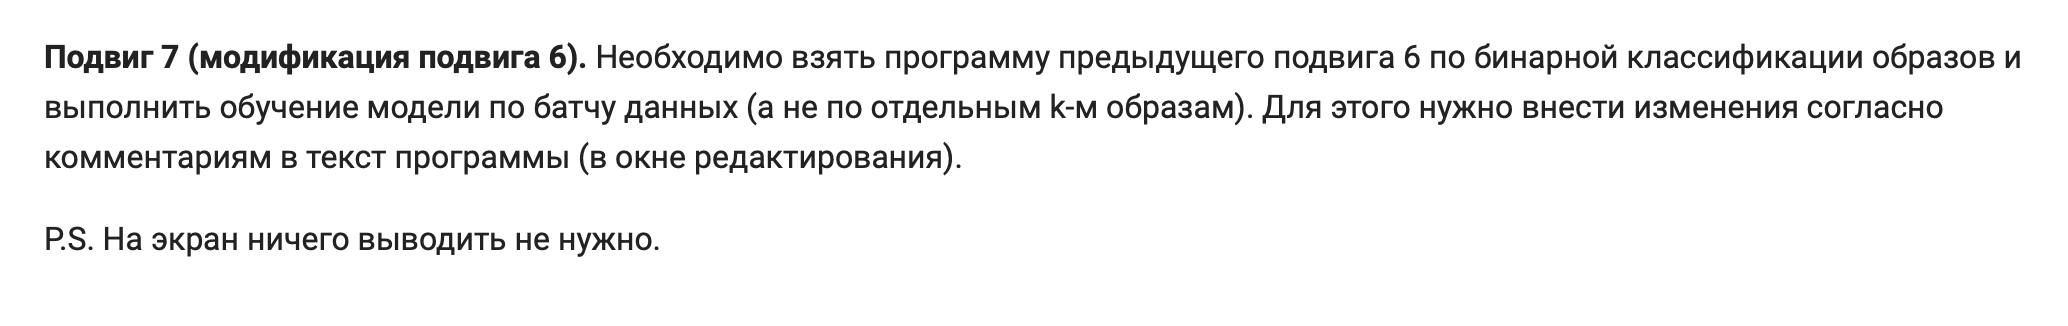

In [56]:
# сюда скопируйте класс ClassModel из предыдущего подвига
class ClassModel(nn.Module):
    def __init__(self, inp, hid, out):
        super().__init__()
        self.l1 = nn.Linear(inp, hid)
        self.l2 = nn.Linear(hid, out)

    def forward(self, x):
        u1 = self.l1(x).relu()
        y = self.l2(u1)

        return y

np.random.seed(1)
torch.manual_seed(1)

# обучающая выборка: x_train - входные значения; y_train - целевые значения
x_train = torch.tensor([(5.8, 1.2), (5.6, 1.5), (6.5, 1.5), (6.1, 1.3), (6.4, 1.3), (7.7, 2.0), (6.0, 1.8), (5.6, 1.3), (6.0, 1.6), (5.8, 1.9), (5.7, 2.0), (6.3, 1.5), (6.2, 1.8), (7.7, 2.3), (5.8, 1.2), (6.3, 1.8), (6.0, 1.0), (6.2, 1.3), (5.7, 1.3), (6.3, 1.9), (6.7, 2.5), (5.5, 1.2), (4.9, 1.0), (6.1, 1.4), (6.0, 1.6), (7.2, 2.5), (7.3, 1.8), (6.6, 1.4), (5.6, 2.0), (5.5, 1.0), (6.4, 2.2), (5.6, 1.3), (6.6, 1.3), (6.9, 2.1), (6.8, 2.1), (5.7, 1.3), (7.0, 1.4), (6.1, 1.4), (6.1, 1.8), (6.7, 1.7), (6.0, 1.5), (6.5, 1.8), (6.4, 1.5), (6.9, 1.5), (5.6, 1.3), (6.7, 1.4), (5.8, 1.9), (6.3, 1.3), (6.7, 2.1), (6.2, 2.3), (6.3, 2.4), (6.7, 1.8), (6.4, 2.3), (6.2, 1.5), (6.1, 1.4), (7.1, 2.1), (5.7, 1.0), (6.8, 1.4), (6.8, 2.3), (5.1, 1.1), (4.9, 1.7), (5.9, 1.8), (7.4, 1.9), (6.5, 2.0), (6.7, 1.5), (6.5, 2.0), (5.8, 1.0), (6.4, 2.1), (7.6, 2.1), (5.8, 2.4), (7.7, 2.2), (6.3, 1.5), (5.0, 1.0), (6.3, 1.6), (7.7, 2.3), (6.4, 1.9), (6.5, 2.2), (5.7, 1.2), (6.9, 2.3), (5.7, 1.3), (6.1, 1.2), (5.4, 1.5), (5.2, 1.4), (6.7, 2.3), (7.9, 2.0), (5.6, 1.1), (7.2, 1.8), (5.5, 1.3), (7.2, 1.6), (6.3, 2.5), (6.3, 1.8), (6.7, 2.4), (5.0, 1.0), (6.4, 1.8), (6.9, 2.3), (5.5, 1.3), (5.5, 1.1), (5.9, 1.5), (6.0, 1.5), (5.9, 1.8)])
y_train = torch.FloatTensor([0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1])

model = ClassModel(2, 3, 1) # здесь создавайте модель
# переведите модель в режим обучения
model.train()

total = x_train.size(0) # размер обучающей выборки
N = 1000 # число итераций алгоритма SGD
batch_size = 8 # размер мини-батча

optimizer = optim.Adam(params=model.parameters(), lr=0.01) # задайте оптимизатор Adam с шагом обучения lr=0.01
loss_func = nn.BCEWithLogitsLoss() # сформируйте функцию потерь (бинарную кросс-энтропию) с помощью класса nn.BCEWithLogitsLoss

for _ in range(N):
    idx = np.random.choice(total, batch_size, False) # выбор индексов образов в размере batch_size
    # с помощью списочной индексации отберите из выборки x_train образы согласно индексам списка idx
    x = x_train[idx]
    # пропустите через модель батч образов выборки и вычислите батч прогнозов predict
    pred = model(x)
    loss = loss_func(pred.squeeze(), y_train[idx]) # вычислите значение функции потерь и сохраните результат в переменной loss

    # выполните один шаг градиентного спуска так, как это было сделано в предыдущем подвиге
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# переведите модель в режим эксплуатации
model.eval()
# прогоните через модель обучающую выборку и подсчитайте долю верных классификаций
# результат (долю верных классификаций) сохраните в переменной Q (в виде вещественного числа, а не тензора)
predict = model(x_train)
Q = torch.mean((torch.sign(predict.flatten()) == (y_train.flatten() * 2 - 1)).float()).item()
Q

0.9300000071525574